In [1]:
import kagglehub
from PIL import Image
import util
import matplotlib.pyplot as plt

In [2]:

path = kagglehub.dataset_download("muhammadrehan00/chest-xray-dataset")
print("Path to dataset files:", path)

Path to dataset files: /Users/madsfjeldberg/.cache/kagglehub/datasets/muhammadrehan00/chest-xray-dataset/versions/1


Output path ./normalized_images already exists. Normalizing only missing files.
Saved 100 normalized images
Saved 200 normalized images
Saved 300 normalized images
Saved 400 normalized images
Saved 500 normalized images
Saved 600 normalized images
Saved 700 normalized images
Saved 800 normalized images
Saved 900 normalized images
Saved 1000 normalized images
Saved 1100 normalized images
Saved 1200 normalized images
Saved 1300 normalized images
Saved 1400 normalized images
Done. Saved 1470 normalized images to ./normalized_images
Skipped 13442 files that were already normalized


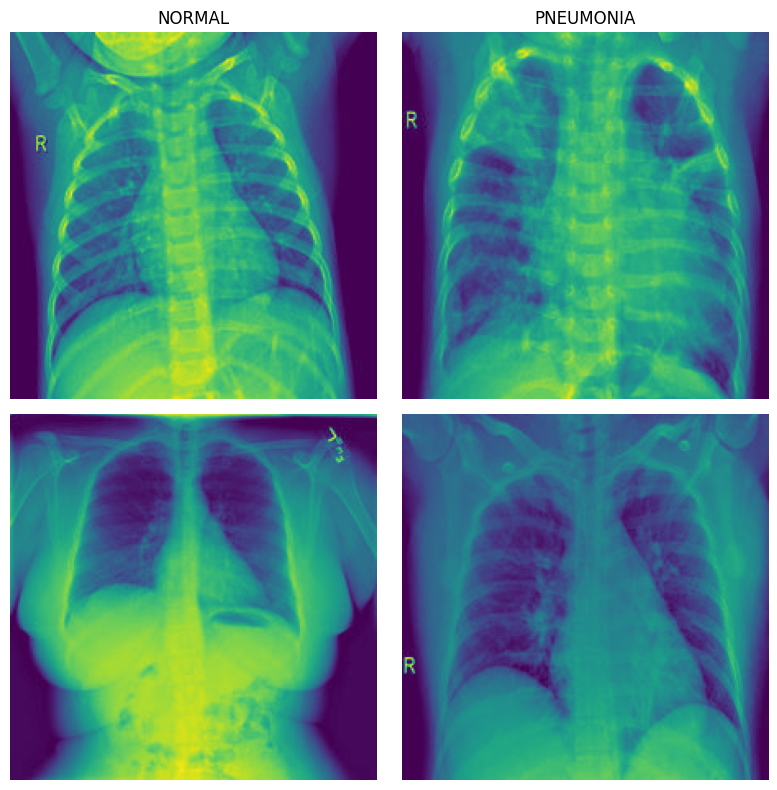

In [3]:
util.normalize_and_save_images(path, output_path="./normalized_images")

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].imshow(Image.open("./normalized_images/train/NORMAL/normal-929.jpg"))
axes[0, 0].set_title("NORMAL")
axes[0, 0].axis("off")
axes[0, 1].imshow(Image.open("./normalized_images/train/PNEUMONIA/pneumonia-581.jpg"))
axes[0, 1].set_title("PNEUMONIA")
axes[0, 1].axis("off")
axes[1, 0].imshow(Image.open("./normalized_images/train/NORMAL/normal-926.jpg"))
axes[1, 0].axis("off")
axes[1, 1].imshow(Image.open("./normalized_images/train/PNEUMONIA/pneumonia-582.jpg"))
axes[1, 1].axis("off")
plt.tight_layout()
plt.show()

path = "./normalized_images"

In [4]:
# print number of files in each set
import os
path = "./normalized_images"

dirnames = ["train", "eval", "test"]
for dirname in ["train", "eval", "test"]:
      dir_path = os.path.join(path, dirname)                                                                                           
      if not os.path.isdir(dir_path):                                                                                                  
          continue                                                                                                                     
      normal    = len(os.listdir(os.path.join(dir_path, "NORMAL")))                                                                    
      pneumonia = len(os.listdir(os.path.join(dir_path, "PNEUMONIA")))                                                                 
      total     = normal + pneumonia                                                                                                   
      print(f"{dirname}: {total} total — NORMAL: {normal}, PNEUMONIA: {pneumonia} ({normal/total*100:.1f}% / {pneumonia/total*100:.1f}%)") 
    
    

train: 11937 total — NORMAL: 7263, PNEUMONIA: 4674 (60.8% / 39.2%)
eval: 1470 total — NORMAL: 900, PNEUMONIA: 570 (61.2% / 38.8%)
test: 1505 total — NORMAL: 925, PNEUMONIA: 580 (61.5% / 38.5%)


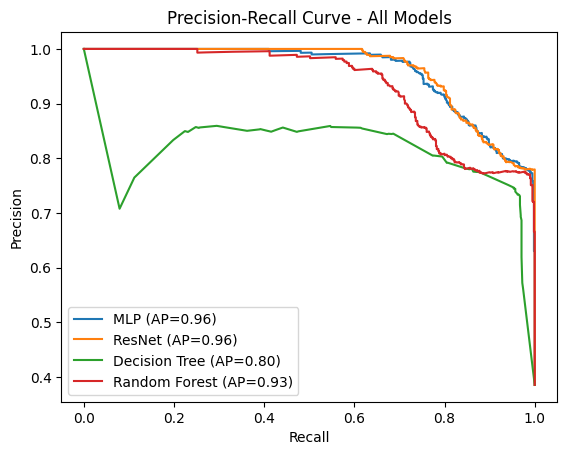

In [5]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

models = {
    "MLP":           ("preds/mlp_test_preds.npy",    "preds/mlp_test_labels.npy"),
    "ResNet":        ("preds/resnet_test_preds.npy",  "preds/resnet_test_labels.npy"),
    "Decision Tree": ("preds/dt_test_preds.npy",      "preds/dt_test_labels.npy"),
    "Random Forest": ("preds/rf_test_preds.npy",      "preds/rf_test_labels.npy"),
}

for name, (preds_path, labels_path) in models.items():
    preds = np.load(preds_path)
    labels = np.load(labels_path)
    precision, recall, _ = precision_recall_curve(labels, preds)
    ap = average_precision_score(labels, preds)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - All Models")
plt.legend()
plt.show()

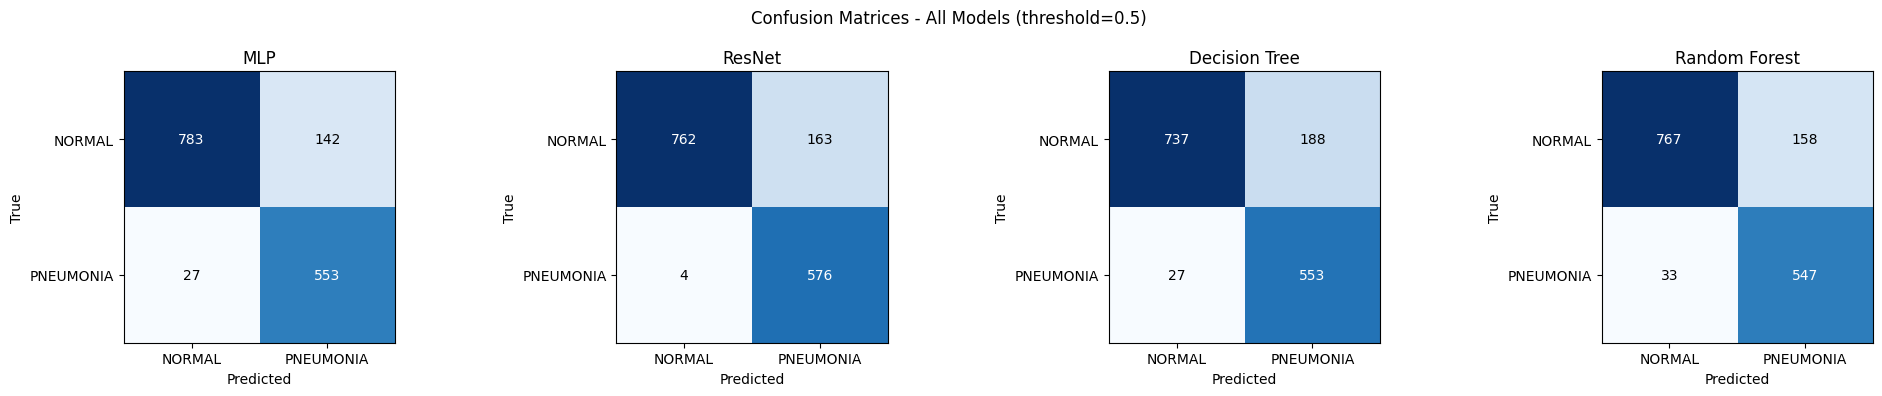

In [6]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

THRESHOLD = 0.5  # lower to e.g. 0.4 to catch more pneumonia cases

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, (preds_path, labels_path)) in zip(axes, models.items()):
    preds = np.load(preds_path)
    labels = np.load(labels_path)
    cm = confusion_matrix(labels, (preds >= THRESHOLD).astype(int))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(name)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["NORMAL", "PNEUMONIA"])
    ax.set_yticklabels(["NORMAL", "PNEUMONIA"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.suptitle(f"Confusion Matrices - All Models (threshold={THRESHOLD})")
plt.tight_layout()
plt.show()

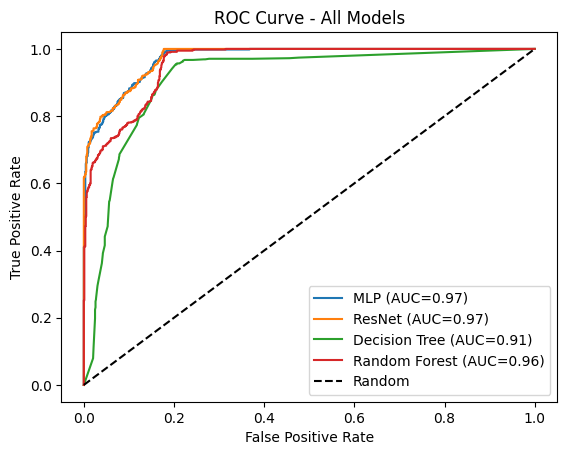

In [7]:
from sklearn.metrics import roc_curve, roc_auc_score

for name, (preds_path, labels_path) in models.items():
    preds = np.load(preds_path)
    labels = np.load(labels_path)
    fpr, tpr, _ = roc_curve(labels, preds)
    auc = roc_auc_score(labels, preds)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All Models")
plt.legend()
plt.show()